In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
from PIL import Image
import pathlib
import jax
import jax.numpy as jnp


from bvhgs import device
from bvhgs.data import SFMDataset
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianCloud
from bvhgs.renderer import Renderer
from bvhgs.prefix_sum import prefix_sum
from bvhgs.radix_sort import radix_sort, numpy_sort

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
np.random.seed(0)

# Load Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"))
len(gaussians)

104692

# Load Module and Shader

In [4]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="bwdCullProjection", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="tileHistogram", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
    SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
    SlangEntryPoint(name="bwdRasterize", stage=compute),
    SlangEntryPoint(name="extractSortedGaussianGrad", stage=compute),
    SlangEntryPoint(name="gradDescentGaussian2D", stage=compute),
  ]
)

In [5]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="bwdCullProjection", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="tileHistogram", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
        SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
        SlangEntryPoint(name="bwdRasterize", stage=compute),
        SlangEntryPoint(name="extractSortedGaussianGrad", stage=compute),
        SlangEntryPoint(name="gradDescentGaussian2D", stage=compute),
      ]
    ),
  ],
  entry_points = []
)

# Build Slang Buffer and Camera Parameter

In [6]:
# Create a buffer for the Gaussian points.
gaussian_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [7]:
sfm_dataset = SFMDataset()
sfm_dataset.load_from_colmap(
    colmap_path=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"),
    image_dir=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
)

{'_rotation': [-0.036209676414728165, 0.9839765429496765, 0.17386838793754578, -0.01577397622168064], '_translation': vec3( -0.225826, -1.05851, 5.25607 ), '_sensorSize': uvec2( 979, 546 ), '_focalLength': 581.9245354745742, '_nearPlane': 0.1, '_farPlane': 1000.0}


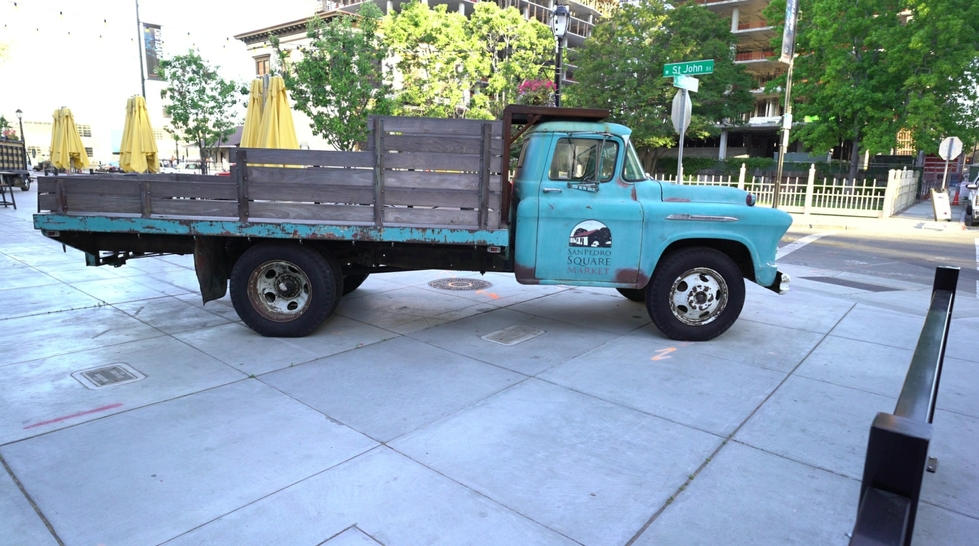

In [8]:
camera, image_path = sfm_dataset[0]
print(camera.to_slang())
image = Image.open(image_path)
image

# Projection

## Dispatch Projection Kernel

In [9]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x11e25e078,
  size = 8375360,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.99 MB,
  label = 
)

In [10]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x11e25e078,
  size = 418768,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 408.95 kB,
  label = 
)

In [11]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x600000b58000)

In [12]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [13]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.3242423, 0.34090775, 0.003679035}, 'covariance': {{6.1337225e-05, -1.1307071e-12}, {-7.6246675e-13, 0.00019719877}}, 'color': {0.27344006, 0.3125016, 0.35546938}, 'opacity': 0.5, 'cachedInvCov': {{16303.313, 9.348067e-05}, {6.3036576e-05, 5071.0254}}} [Gaussian2D]

## Cull Gaussians

In [14]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [15]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

97533

In [16]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x11e25e078,
  size = 7802640,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.44 MB,
  label = 
)

In [17]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [18]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.3242423, 0.34090775, 0.003679035}, 'covariance': {{6.1337225e-05, -1.1307071e-12}, {-7.6246675e-13, 0.00019719877}}, 'color': {0.27344006, 0.3125016, 0.35546938}, 'opacity': 0.5, 'cachedInvCov': {{16303.313, 9.348067e-05}, {6.3036576e-05, 5071.0254}}} [Gaussian2D]

# Tiling

In [19]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [20]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tiles,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x11e25e078,
  size = 390132,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 380.99 kB,
  label = 
)

In [21]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles": num_tile_buf
    }
)

In [22]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

403470

In [23]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x11e25e078,
  size = 6455520,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 6.16 MB,
  label = 
)

In [24]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [25]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [26]:
numpy_sort(gaussian_table_buf)

In [27]:
ker_tile_hist = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("tileHistogram")])
)

In [28]:
hist_buf = device.create_buffer(
    element_count=2**8,
    struct_type=program.reflection.g_tile_hist_atomic,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
# Compute the histogram of the Gaussian table.
ker_tile_hist.dispatch(
    thread_count=[num_table_entries, 1, 1],
    numEntries=num_table_entries,
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "g_tile_hist_atomic": hist_buf,
    },
)

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



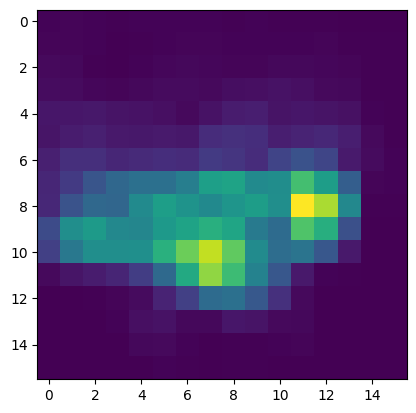

In [29]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [30]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [31]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x11e25e078,
  size = 32277600,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 30.78 MB,
  label = 
)

In [32]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [33]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [34]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [35]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [36]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target
    }
)

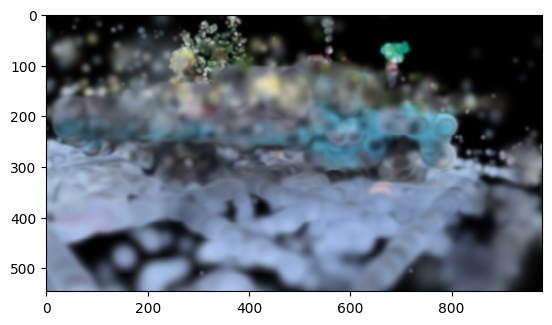

In [37]:
raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
plt.imshow(raw_image)

# Image Loss

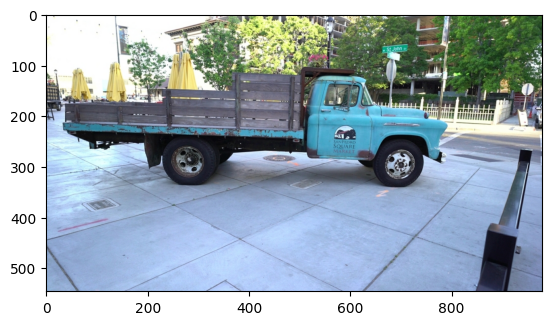

In [38]:
image_arr = jnp.array(image)
plt.imshow(image_arr)

In [39]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [40]:
image_loss(raw_image, image_arr)

Array(27693.742, dtype=float32)

In [41]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

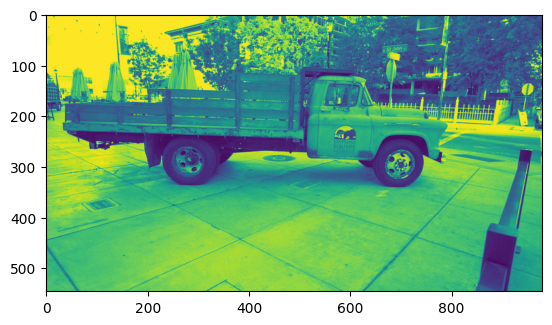

In [42]:
loss, render_target_grad = loss_grad(raw_image, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

In [43]:
render_target_grad.shape

(546, 979, 3)

In [44]:
rg_shape = render_target_grad.shape
render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
render_target_grad.shape

(546, 979, 4)

# Backward Gradient into Slang

In [45]:
ker_bwd_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdRasterize")])
)
ker_grad_descent = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("gradDescentGaussian2D")])
)

In [46]:
grad_texture = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [47]:
grad_texture.copy_from_numpy(render_target_grad)

In [48]:
a_gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_a_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

In [49]:
ker_bwd_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "d_render_target": grad_texture,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf
    }
)

[WARN] (rhi) slang: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(254): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
    this.position[0].add(g.position.x);
                        ^
/Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(255): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
    this.position[1].add(g.position.y);
                        ^
/Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(256): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
    this.position[2].add(g.position.z);
                        ^
/Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/gaussian.slang(257): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
    this.covariance[0][0].add(g.covariance

In [50]:
ker_grad_descent.dispatch(
    thread_count=[num_table_entries, 1, 1],
    lr=1e-2,
    vars={
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf
    }
)

## A Very Simple Gradient Descent